In [1]:
''' This does all the prep for making a BlendedMLP: it splits a mesh into patches
using geodesics, and parametrises the patches using Tutte's embedding. '''


import trimesh
import open3d as o3d
import numpy as np

from scipy.spatial import cKDTree
from mesh_processing import *
import matplotlib.pyplot as plt

import os
import shutil
from visuals import *

original_cwd = os.getcwd()

In [2]:
# Settings
shape_name = 'camelhead' #'torus4608' #'sphere4'   #'sphere2' #'camelhead'


In [3]:
''' Load mesh (fine_mesh) and make a simplified mesh (coarse_mesh) '''

# Paths
off_filepath = f"data/surfaces/{shape_name}.off"
obj_filepath = f"data/surfaces/{shape_name}.obj"

# Check if .off file exists
if not os.path.exists(off_filepath):
    if os.path.exists(obj_filepath):
        print(f"{off_filepath} not found. Converting from .obj...")
        mesh = o3d.io.read_triangle_mesh(obj_filepath)
        mesh.vertex_normals = o3d.utility.Vector3dVector()  # Clear vertex normals
        mesh.triangle_normals = o3d.utility.Vector3dVector()  # Clear triangle normals
        o3d.io.write_triangle_mesh(off_filepath, mesh)
    else:
        raise FileNotFoundError(f"Neither {off_filepath} nor {obj_filepath} found.")

# Load mesh from .off
fine_mesh = o3d.io.read_triangle_mesh(off_filepath)

n_triangles = 1

patches_name = shape_name + '_'+str(n_triangles)+'patch'


os.makedirs('patches/'+patches_name, exist_ok=True)

V_fine = np.asarray(fine_mesh.vertices)


o3d.io.write_triangle_mesh("patches/"+patches_name+"/"+str(0)+".obj", fine_mesh)




True

In [4]:
# Make halfedge meshes, including a halfedge index for each vertex.

fine_he_mesh, fine_V_he = he_mesh_from_o3d(fine_mesh)

Preparing V_he for halfedge mesh
10000 of 68112
20000 of 68112
30000 of 68112
40000 of 68112
50000 of 68112
60000 of 68112
Prepared V_he for halfedge mesh.



In [ ]:
F = np.asarray(fine_he_mesh.triangles)
boundary = list ( igl.boundary_loop(F) )
n = len(boundary)
coarse_triangle_vtx_indices = [ boundary[0], boundary[n//3], boundary[2*n//3] ]


# write coarse obj file
# add 'special indices' to fine mesh file

patches/camelhead_1patch/0.obj
boundary: [6320, 11318, 6324, 11213, 6329, 11319, 6333, 11214, 6338, 11320, 6342, 11215, 11321, 6345, 6346, 11211, 11212, 11299, 11210, 11209, 11352, 8383, 8367, 8362, 11218, 11219, 11351, 11207, 11208, 11295, 11206, 9739, 8317, 8318, 8321, 8322, 11348, 8326, 11216, 8333, 11349, 8337, 11217, 8343, 8350, 11350, 8357, 9987, 11224, 11225, 11370, 11222, 11223, 11369, 11221, 11220]
[6320, 11210, 8326]
Tutte-style harmonic embedding completed. UVs saved to patches/camelhead_1patch/0_param.obj


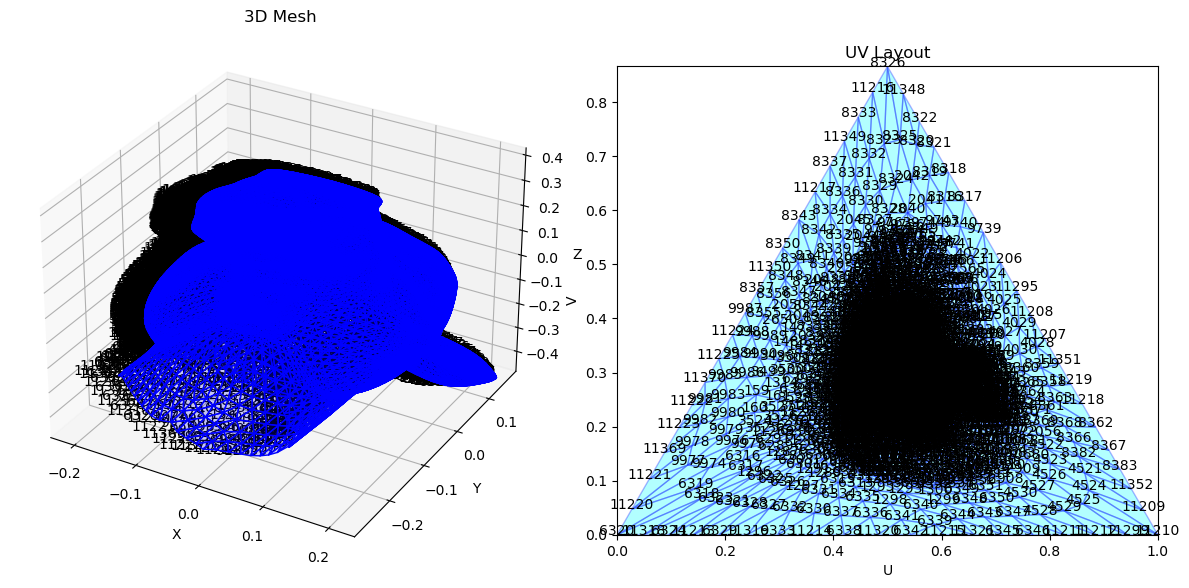

boundary: [6320, 11318, 6324, 11213, 6329, 11319, 6333, 11214, 6338, 11320, 6342, 11215, 11321, 6345, 6346, 11211, 11212, 11299, 11210, 11209, 11352, 8383, 8367, 8362, 11218, 11219, 11351, 11207, 11208, 11295, 11206, 9739, 8317, 8318, 8321, 8322, 11348, 8326, 11216, 8333, 11349, 8337, 11217, 8343, 8350, 11350, 8357, 9987, 11224, 11225, 11370, 11222, 11223, 11369, 11221, 11220]
coarse_triangle_vtx_indices: [6320, 11210, 8326]


In [7]:
''' Finally, parametrise the patch '''


import importlib
import visuals
importlib.reload(visuals)

from visuals import *

import mesh_processing
importlib.reload(mesh_processing)

from mesh_processing import *



input_filename = "patches/"+patches_name+"/"+str(0)+".obj"
output_filename = "patches/"+patches_name+"/"+str(0)+"_param.obj"

print(input_filename)
tutte_embedding(input_filename, output_filename, visualise=False)